## EarthCARE ESA MAAP Data Access Example  

@ ESA, 2025
= Licensed under "European Space Agency Community License" 

In this example we will use the pystac_client package to search for `MSI_COP_2A` products on ESA MAAP. 

An [EO Sign in](https://eoiam-idp.eo.esa.int/) account is required to access EarthCARE data from ESA MAAP. 

At the end of this notebook you will know:

- How to get and use your ESA MAAP data access token. 
- How to use the STAC API and the pystac_client library to serach for Aeolus data using search filters.
- How to avoid downloading data.


### Prerequisities

In [1]:
from pystac_client import Client
import fsspec
import xarray as xr
import matplotlib.pyplot as plt
from tqdm import tqdm
import requests
from IPython.display import Image, display
import pathlib

### Using the STAC API to query the ESA MAAP stac catalog
While the discovery of data (querying the ESA MAAP catalogue) does not require any authentication or authorization, accessing the data requires a token generated with an authorized ESA account (EO Sign in) to verify the user. This is the same account and credentials you will have used for the OADS system.


In [2]:
catalog_url = 'https://catalog.maap.eo.esa.int/catalogue/'
catalog = Client.open(catalog_url)

The EarthCARE collections have the same name as previously on OADS, but have the extension `_MAAP` to distinguish them from the OADS collections. Currently the latest two baselines are provided and there are 12 collections: 

| **Restricted to special users** | **Restricted CalVal users** |  **Open and Free**|
|-------------------|---------------------------------|-----------------------------|
| EarthCAREL1InstChecked_MAAP  | EarthCAREL0L1Products_MAAP      | EarthCAREL1Validated_MAAP   |
| EarthCAREL2InstChecked_MAAP                  | EarthCAREL2Products_MAAP        | EarthCAREL2Validated_MAAP   |
|      JAXAL2InstChecked_MAAP             |              EarthCAREAuxiliary_MAAP                | JAXAL2Validated_MAAP |
|      EarthCAREOrbitData_MAAP             |              JAXAL2Products_MAAP                |  |
|          EarthCAREXMETL1DProducts10_MAAP         |                              |  |


The **first** step is to select a collection. 
You can select multiple collections by extending the list. Note that if you pass multiple collections, the query filters you use must exist across both collections!

In [3]:
# Select one or more collection(s)
EC_COLLECTION = ['EarthCAREL2Validated_MAAP']

The **second** step is to further narrow down your search: 

**Datetime** represents the temporal coverage of the data. None can be used for both start and end to indicated unbounded queries.  

**bbox** is defined by the bottom left corner (longmin latmin) and the top right corner coordinates (longmax latmax). The default is [-180,-90,180,90].

**Filter** – allows you to search based on different metadata parameters.  
To understand which queryables exist, you can visit:  
``https://catalog.maap.eo.esa.int/catalogue/collections/NAMEOFCOLLECTION/queryables``

Multiple filters can be combined with _or_ and _and_ following a boolean type of logic. 

Examples include: 
* productType
* frame 
* processingLevel
* instrument
* orbitNumber 



In [4]:
search = catalog.search(
    collections=EC_COLLECTION, 
    filter="productType = 'MSI_COP_2A' and orbitNumber > 5000", # For example filter by product type and orbitNumber. Use boolean logic for multi-filter queries
    bbox = [0, -20, 10, -10], # Filter by area 
    datetime = ['2025-10-01T00:00:00Z', '2025-12-31T23:59:59Z'], # Filter by date
    method = 'GET', # This is necessary 
    max_items=5  # Adjust as needed, given the large amount of products it is recommended to set a limit if especially if you display results in pandas dataframe or similiar
)
items = list(search.items()) # Get all items as a list
results = search.matched()

print(f"{results} items found that matched the query.")
print(f"Accessing {len(items)} items (limited by max_items).")

107 items found that matched the query.
Accessing 5 items (limited by max_items).


In [5]:
# OPTIONAL: Inspect results 
for item in items:
    print(f"Item ID: {item.id}")
    print(f"  - Datetime: {item.datetime}")
    print(f"  - BBOX: {item.bbox}")
    print(f"  - Properties: {item.properties}")
    print(f"  - Assets: {list(item.assets.keys())}")
    print()

Item ID: ECA_EXBA_MSI_COP_2A_20251013T131444Z_20251013T162407Z_07820E
  - Datetime: 2025-10-13 13:14:44+00:00
  - BBOX: [4.13775, -22.718754, 14.422692, 22.589455]
  - Properties: {'start_datetime': '2025-10-13T13:14:44.000Z', 'end_datetime': '2025-10-13T13:26:20.000Z', 'processing:facility': 'PDGS-CPFxx', 'product:type': 'MSI_COP_2A', 'sat:anx_datetime': '2025-10-13T12:34:19.778Z', 'title': 'ECA_EXBA_MSI_COP_2A_20251013T131444Z_20251013T162407Z_07820E', 'platform': 'EarthCARE', 'datetime': '2025-10-13T13:14:44.000Z', 'instruments': ['MSI'], 'constellation': 'EarthCARE', 'sat:orbit_state': 'descending', 'processing:software': {'M-CLD': '11.30'}, 'grid:code': 'WRS-7820-E', 'processing:level': 'L2A', 'sci:doi': '10.57780/eca-94b4e53', 'created': '2025-10-13T16:24:07.000Z', 'published': '2025-10-17T11:36:12.056Z', 'version': 'BA', 'auth:schemes': {'s3': {'type': 's3'}, 'oidc': {'openIdConnectUrl': 'https://iam.ascend.icsgate.eu/realms/esa-maap/.well-known/openid-configuration', 'type': 'o

In [6]:
# Choose one item
ec_product = items[1]

### Results

Assets in the ESA MAAP STAC Catalog: Each granule (one frame of EarthCARE data per product) includes multiple **assets**, which are different files that serve distinct purposes. These assets can include preview images, scientific data, metadata, and more.

In [7]:
# Optional: Inspect available assets 
for asset_key, asset in ec_product.assets.items():
        print(f"  Asset key: {asset_key}")
        print(f"    href: {asset.href}")
        print(f"    type: {asset.media_type}")
        print(f"    roles: {asset.roles}")

  Asset key: thumbnail
    href: https://catalog.maap.eo.esa.int/data/earthcare-pdgs-01/EarthCARE/MSI_COP_2A/BA/2025/10/20/ECA_EXBA_MSI_COP_2A_20251020T132215Z_20251020T162940Z_07929E/public/ECA_EXBA_MSI_COP_2A_20251020T132215Z_20251020T162940Z_07929E.BID_1.jpeg
    type: image/jpeg
    roles: ['thumbnail']
  Asset key: product
    href: https://catalog.maap.eo.esa.int/data/zipper/earthcare-pdgs-01/EarthCARE/MSI_COP_2A/BA/2025/10/20/ECA_EXBA_MSI_COP_2A_20251020T132215Z_20251020T162940Z_07929E/ECA_EXBA_MSI_COP_2A_20251020T132215Z_20251020T162940Z_07929E
    type: application/zip
    roles: ['data', 'metadata', 'archive']
  Asset key: metadata_ogc_10_157r4
    href: https://catalog.maap.eo.esa.int/catalogue/collections/EarthCAREL2Validated_MAAP/items/ECA_EXBA_MSI_COP_2A_20251020T132215Z_20251020T162940Z_07929E?httpAccept=application/gml%2Bxml&recordSchema=om
    type: application/gml+xml;profile="http://www.opengis.net/spec/EOMPOM/1.1"
    roles: ['metadata']
  Asset key: enclosure_h5
  


**Tips**: 

- **Want a quick look?** Use the quicklook or thumbnail to preview the data.
- **Need to analyze?** Work with the enclosure files as demonstrated in the scripts later on.
- **Don't need everything?** Avoid the .zip unless you really need to download all files.
- **Curious about metadata?** Open the XML/JSON metadata files for detailed info.



### Quicklook of the data

You don't need to authenticate or authorize to preview the data.  
By referencing the `thumbnail` pr `quicklook_jpeg` asset, you're accessing a remote URL where a quicklook image of the product is stored.  Note that not all products necessarily have a quicklook stored.
This provides a fast and convenient way to visually inspect the data before downloading or processing it.


In [8]:
ql_url = ec_product.assets['thumbnail'].href
display(Image(url= ql_url))

### Token
You can generate an offline access token that is valid for 90 days [here](https://portal.maap.eo.esa.int/ini/services/auth/token/90dToken.php). We recommend to save this personal offline token in a separate file and not paste it into your scripts. This offline access token in combination with a client ID and secret creates a refresh token which authenticates/authorizes you to access the data files. In simple terms, the offline token is like a temporary key that helps you securely log in without needing to re-enter your credentials every time.


In [9]:
# offline token link: https://portal.maap.eo.esa.int/ini/services/auth/token/90dToken.php
# CLIENT_ID and CLIENT_SECRET are valid permanently for EVERYONE, but you need to use your own offline token in combination with this. 
CLIENT_ID="offline-token"
CLIENT_SECRET="p1eL7uonXs6MDxtGbgKdPVRAmnGxHpVE"
# Save your personal offline token in a text file token_yourname.txt in the same directory as this script

In [14]:
# TODO: Create (and rename) token_yourname.txt with your own offline token and place it in the same directory as this script. Then you can run the code below to retrieve an access token that is needed for downloading data.
if pathlib.Path("credentials.txt").exists():
  with open("credentials.txt","rt") as f:
    OFFLINE_TOKEN = f.read().strip().replace("\n","")
    url = "https://iam.maap.eo.esa.int/realms/esa-maap/protocol/openid-connect/token"
    data = {
        "client_id": CLIENT_ID,
        "client_secret": CLIENT_SECRET,
        "grant_type": "refresh_token",
        "refresh_token": OFFLINE_TOKEN,
        "scope": "offline_access openid"
    }

    response = requests.post(url, data=data)
    response.raise_for_status()

    response_json = response.json()
    access_token = response_json.get('access_token')
    print("Access token retrieved successfully.")

    if not access_token:
        raise RuntimeError("Failed to retrieve access token from IAM response")

Access token retrieved successfully.


## Stream and plot data

In [15]:
# Fetching the url of the desired file
ds_url = ec_product.assets.get('enclosure_h5').href  # Updated to enclosure_h5
print(f"Dataset URL: {ds_url}")

Dataset URL: https://catalog.maap.eo.esa.int/data/earthcare-pdgs-01/EarthCARE/MSI_COP_2A/BA/2025/10/20/ECA_EXBA_MSI_COP_2A_20251020T132215Z_20251020T162940Z_07929E/ECA_EXBA_MSI_COP_2A_20251020T132215Z_20251020T162940Z_07929E/ECA_EXBA_MSI_COP_2A_20251020T132215Z_20251020T162940Z_07929E.h5


This provides a faster way to access the NetCDF data in the cloud. It configures how the HDF5 (.h5) files are read and cached.

In [16]:
io_params = {
    "fsspec_params": {
        "cache_type": "blockcache",
        "block_size": 8 * 1024 * 1024
    },
    "h5py_params": {
        "driver_kwds": {
            "rdcc_nbytes": 8 * 1024 * 1024
        }
    }
}

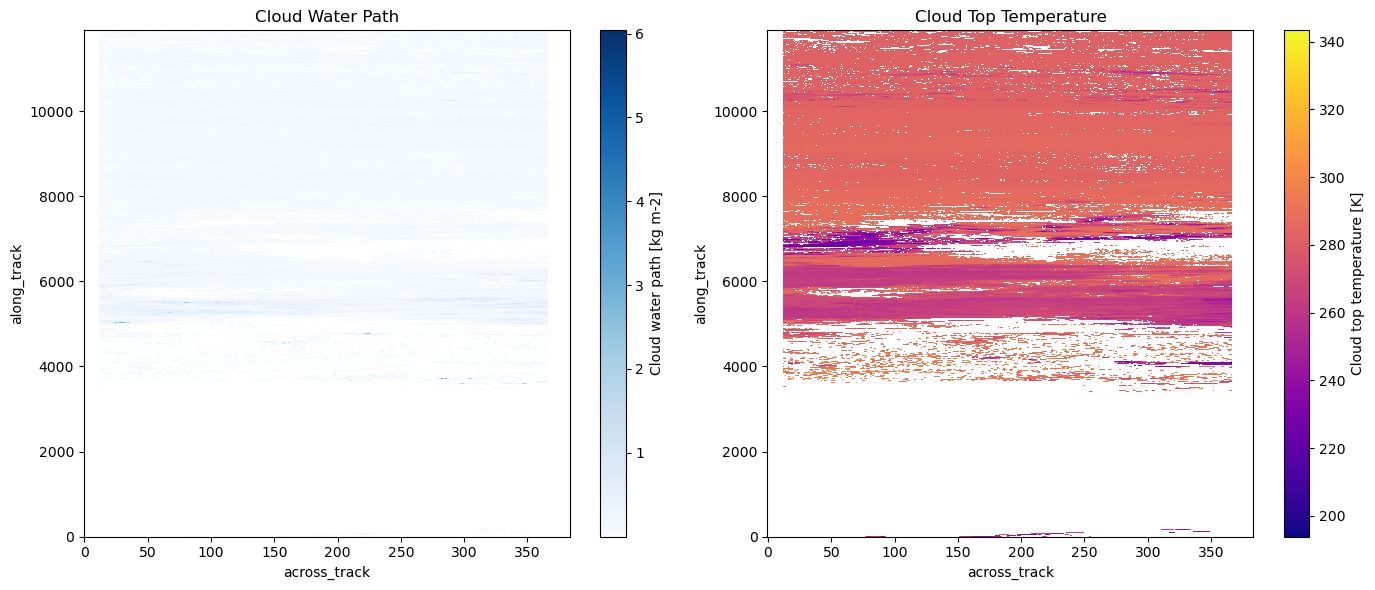

In [17]:
fs = fsspec.filesystem(
    "https", 
    headers={"Authorization": f"Bearer {access_token}"}, 
    **io_params["fsspec_params"]  )

# Open the file and read it into an xarray Dataset
with fs.open(ds_url, "rb") as f:
    ds = xr.open_dataset(f, 
                         engine="h5netcdf", 
                         **io_params["h5py_params"],  
                         group="ScienceData")
    
    # Do something with ds! Here we plot two variables as an example.
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot Cloud Water Path
    ds["cloud_water_path"].plot(ax=axes[0], cmap="Blues")
    axes[0].set_title("Cloud Water Path")

    # Plot Cloud Top Temperature
    ds["cloud_top_temperature"].plot(ax=axes[1], cmap="plasma")
    axes[1].set_title("Cloud Top Temperature")

    plt.tight_layout()
    plt.show()
    